# albis tutorial

This notebook demonstrates the app-facing `albis` workflow:

1. generate one synthetic spatial-transcriptomics dataset,
2. inspect the returned `AnnData`,
3. plot aligned and unaligned coordinates,
4. save the result as `.h5ad`.

It uses small settings so the tutorial stays interactive.

## Setup

Install Albis, including plotting support, in your Python environment:

```bash
pip install albis
```

Download this notebook and open it in Jupyter using the same environment.
If Jupyter is not already installed:

```bash
pip install notebook
jupyter notebook
```

If you are already in a notebook, run `%pip install albis` in a cell to
install into the active kernel, then restart the kernel if needed.


In [1]:
from pathlib import Path

import albis as ab

print("Albis version:", ab.__version__)


Albis version: 0.1.2


## Generate a small bin-level dataset

`generate_data()` returns exactly one `AnnData` object for the requested output type and slice axis.

In [2]:
adata = ab.generate_data(
    output="bin",
    slice_axis="Z",
    n_cells=3000,
    n_slices=4,
    n_domains=5,
    marker_genes_per_type=20,
    sphere_radius_um=200.0,
    capture_window_um=(300.0, 300.0),
    bin_size_um=30.0,
    seed=2025,
)

adata

/dcs04/hicks/data/Jan/sim_project/albis/env/albis-tutorial/lib/python3.10/site-packages/albis/simulation_sphere.py:1793: UserWarning: domain_type_mix was not provided and (n_domains=5, n_cell_types=4) does not match the built-in (4, 4) example composition, so every domain will be assigned the exact same uniform cell-type distribution (no domain-specific enrichment at all). Pass an explicit domain_type_mix of shape (5, 4) if domains should differ in cell-type composition.
  return simulate_3d_molecule_sphere_multires(**kwargs)


AnnData object with n_obs × n_vars = 400 × 73
    obs: 'slice_axis', 'slice_id', 'bin_size_um', 'window_center0', 'window_center1', 'window_size0', 'window_size1', 'plane_dim0', 'plane_dim1', 'cell_type_true', 'domain_true', 'is_empty'
    var: 'gene_class', 'is_noise', 'is_shared_marker'
    uns: 'batch_effect_factors', 'rigid_perturb_inplane', 'sim_params', 'output'
    obsm: 'spatial', 'cell_type_frac_true', 'domain_frac_true', 'spatial_3d', 'spatial_unaligned', 'spatial_3d_unaligned'
    layers: 'counts_pre_batch'

## Inspect the returned object

`describe()` gives a compact summary of the app-relevant fields.

In [3]:
summary = ab.describe(adata)
summary

{'n_obs': 400,
 'n_vars': 73,
 'total_counts': 930427,
 'nonzero_counts': 27341,
 'platform': 'bin',
 'slice_axis': 'Z',
 'n_slices': 4,
 'slice_ids': [0, 1, 2, 3],
 'obs_columns': ['slice_axis',
  'slice_id',
  'bin_size_um',
  'window_center0',
  'window_center1',
  'window_size0',
  'window_size1',
  'plane_dim0',
  'plane_dim1',
  'cell_type_true',
  'domain_true',
  'is_empty'],
 'var_columns': ['gene_class', 'is_noise', 'is_shared_marker'],
 'layers': ['counts_pre_batch'],
 'obsm_keys': ['spatial',
  'cell_type_frac_true',
  'domain_frac_true',
  'spatial_3d',
  'spatial_unaligned',
  'spatial_3d_unaligned'],
 'uns_keys': ['batch_effect_factors',
  'rigid_perturb_inplane',
  'sim_params',
  'output'],
 'truth_annotations': ["layers['counts_pre_batch']",
  "obs['cell_type_true']",
  "obs['domain_true']",
  "obsm['cell_type_frac_true']",
  "obsm['domain_frac_true']"]}

In [4]:
adata.obs.head()

,slice_axis,slice_id,bin_size_um,window_center0,window_center1,window_size0,window_size1,plane_dim0,plane_dim1,cell_type_true,domain_true,is_empty
0,Z,0,30.0,0.0,0.0,300.0,300.0,X,Y,unassigned,unassigned,True
1,Z,0,30.0,0.0,0.0,300.0,300.0,X,Y,type3,D2,False
2,Z,0,30.0,0.0,0.0,300.0,300.0,X,Y,type3,D2,False
3,Z,0,30.0,0.0,0.0,300.0,300.0,X,Y,type1,D2,False
4,Z,0,30.0,0.0,0.0,300.0,300.0,X,Y,type3,D2,False


In [5]:
adata.var.head()

,gene_class,is_noise,is_shared_marker
G1,marker_shared,False,True
G2,marker_shared,False,True
G3,marker_shared,False,True
G4,marker_shared,False,True
G5,marker_shared,False,True


## Plot aligned and unaligned coordinates

`plot()` returns a Matplotlib figure. Use `coordinates="aligned"` for canonical tissue coordinates and `coordinates="unaligned"` for the per-slice rigid transforms.

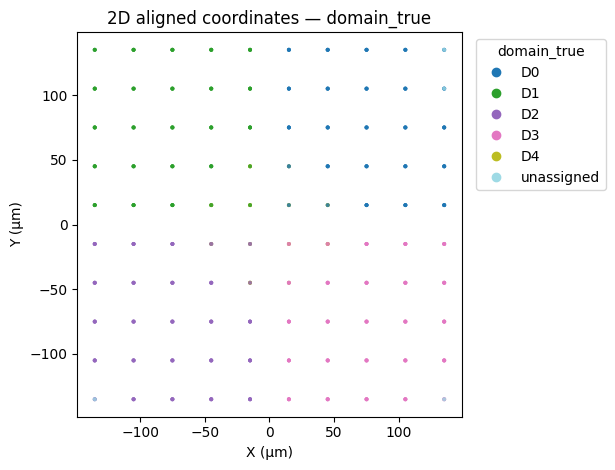

In [6]:
fig = ab.plot(
    adata,
    view="2d",
    coordinates="aligned",
    color="domain_true",
    point_size=8,
)


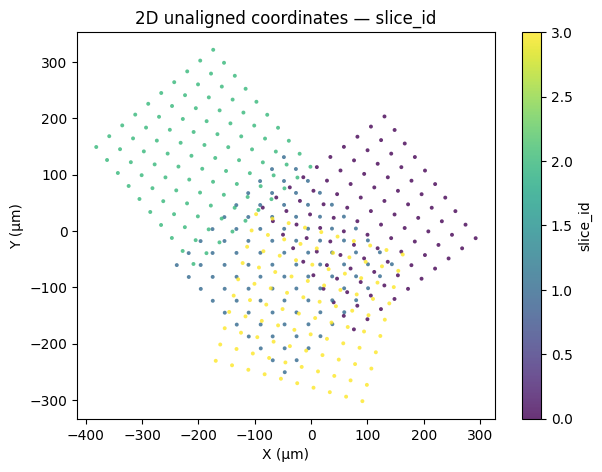

In [7]:
fig = ab.plot(
    adata,
    view="2d",
    coordinates="unaligned",
    color="slice_id",
    point_size=8,
)


## Generate other app outputs

Use the same public API for spot-level or cell-level data. Only the requested output is generated.

In [8]:
spot_adata = ab.example_data(output="spot", slice_axis="Y", n_cells=200)
ab.describe(spot_adata)

{'n_obs': 48,
 'n_vars': 289,
 'total_counts': 50529,
 'nonzero_counts': 5901,
 'platform': 'spot',
 'slice_axis': 'Y',
 'n_slices': 3,
 'slice_ids': [0, 1, 2],
 'obs_columns': ['slice_axis',
  'slice_id',
  'spot_spacing_um',
  'spot_radius_um',
  'window_center0',
  'window_center1',
  'window_size0',
  'window_size1',
  'plane_dim0',
  'plane_dim1',
  'cell_type_true',
  'domain_true',
  'is_empty'],
 'var_columns': ['gene_class', 'is_noise', 'is_shared_marker'],
 'layers': ['counts_pre_batch'],
 'obsm_keys': ['spatial',
  'cell_type_frac_true',
  'domain_frac_true',
  'spatial_3d',
  'spatial_unaligned',
  'spatial_3d_unaligned'],
 'uns_keys': ['batch_effect_factors',
  'rigid_perturb_inplane',
  'sim_params',
  'output'],
 'truth_annotations': ["layers['counts_pre_batch']",
  "obs['cell_type_true']",
  "obs['domain_true']",
  "obsm['cell_type_frac_true']",
  "obsm['domain_frac_true']"]}

In [9]:
cell_adata = ab.example_data(output="cell", slice_axis="X", n_cells=200)
ab.describe(cell_adata)

{'n_obs': 180,
 'n_vars': 289,
 'total_counts': 236653,
 'nonzero_counts': 38847,
 'platform': 'cell',
 'slice_axis': 'X',
 'n_slices': 3,
 'slice_ids': [0, 1, 2],
 'obs_columns': ['domain_true',
  'cell_type_true',
  'cell_radius',
  'cell_sigma_for_95pct',
  'slice_id_X',
  'slice_id_Y',
  'slice_id_Z',
  'slice_axis',
  'slice_id'],
 'var_columns': ['gene_class', 'is_noise', 'is_shared_marker'],
 'layers': ['counts_pre_batch'],
 'obsm_keys': ['spatial',
  'spatial_3d',
  'spatial_unaligned',
  'spatial_3d_unaligned'],
 'uns_keys': ['sim_params',
  'batch_effect_factors',
  'rigid_perturb_inplane',
  'output'],
 'truth_annotations': ["layers['counts_pre_batch']",
  "obs['cell_type_true']",
  "obs['domain_true']",
  "obs['cell_radius']",
  "obs['cell_sigma_for_95pct']"]}

## Matching unaligned perturbations across modalities

By default, each modality draws its own independent per-slice rotation/translation for `spatial_unaligned`, even with identical `base_seed_unaligned` -- so `output="bin"` and `output="spot"` calls above with the same seed still get different unaligned coordinates. Pass `sync_unaligned_seed=True` (and matching `sphere_radius_um`/`slice_axis`/`base_seed_unaligned`/`max_deg`/`max_shift`/`seed` in every call) to make all modalities share the same per-slice transform instead -- useful for comparing how different modalities' own alignment method resolves an identical starting misalignment.

In [10]:
shared = dict(
    slice_axis="Z",
    sphere_radius_um=200.0,
    n_cells=200,
    n_slices=3,
    base_seed_unaligned=12345,
    sync_unaligned_seed=True,
)
bin_synced = ab.example_data(output="bin", **shared)
spot_synced = ab.example_data(output="spot", **shared)

perturb_bin = bin_synced.uns["rigid_perturb_inplane"]["spatial_unaligned"]["1"]
perturb_spot = spot_synced.uns["rigid_perturb_inplane"]["spatial_unaligned"]["1"]
print("bin  slice 1 shift:", perturb_bin["t"])
print("spot slice 1 shift:", perturb_spot["t"])
assert perturb_bin["t"] == perturb_spot["t"] and perturb_bin["R"] == perturb_spot["R"]

bin  slice 1 shift: [102.46703596844094, -47.36821674933012]
spot slice 1 shift: [102.46703596844094, -47.36821674933012]


## Watch out: `domain_type_mix` and non-default domain/cell-type counts

`generate_data()` lets you change `n_domains`/`n_cell_types` freely, but if
you do and don't also supply `domain_type_mix`, every domain silently gets
an identical, fully uniform cell-type distribution -- no domain-specific
enrichment at all. This raises a `UserWarning` so it's impossible to miss:


In [11]:
import warnings

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    _ = ab.generate_data(output="cell", n_cells=200, n_domains=3, n_cell_types=5)
    domain_mix_warnings = [str(w.message) for w in caught if "domain_type_mix" in str(w.message)]

print(domain_mix_warnings[0] if domain_mix_warnings else "(no warning raised)")


domain_type_mix was not provided and (n_domains=3, n_cell_types=5) does not match the built-in (4, 4) example composition, so every domain will be assigned the exact same uniform cell-type distribution (no domain-specific enrichment at all). Pass an explicit domain_type_mix of shape (3, 5) if domains should differ in cell-type composition.


Fix it by supplying your own `(n_domains, n_cell_types)` matrix -- each row
gets renormalized to a probability distribution automatically, so it doesn't
need to sum to exactly 1:


In [12]:
import numpy as np

my_mix = np.array([
    [0.6, 0.2, 0.1, 0.05, 0.05],   # domain 0: enriched for type 0
    [0.1, 0.6, 0.2, 0.05, 0.05],   # domain 1: enriched for type 1
    [0.2, 0.2, 0.2, 0.2, 0.2],     # domain 2 (core): uniform, on purpose
])

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    adata_custom_mix = ab.generate_data(
        output="cell", n_cells=200, n_domains=3, n_cell_types=5, domain_type_mix=my_mix,
    )
    print("warnings raised:", len(caught))


warnings raised: 0


## Save the result

`save()` writes the object with AnnData's `.h5ad` format and returns the output path.

In [13]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

output_path = ab.save(adata, output_dir / "simulation_bins_z.h5ad")
output_path

PosixPath('outputs/simulation_bins_z.h5ad')